# Blog Writer Agent
Generated from `backend.py`

In [ ]:
## Imports & Setup
from __future__ import annotations

import operator
import os
import re
from datetime import date, timedelta
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field
from pprint import pprint

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)

# Debug: Print loaded variables
# print(f"TAVILY_API_KEY: {os.getenv('TAVILY_API_KEY')[:4]}...")
print(f"BASE_URL: {os.getenv('BASE_URL')}")
print(f"MODEL_NAME: {os.getenv('MODEL_NAME')}")



BASE_URL: http://127.0.0.1:1234/v1
MODEL_NAME: qwen3.5-0.8b


## Schemas

In [33]:
# ============================================================
# Blog Writer (Router → (Research?) → Orchestrator → Workers → ReducerWithImages)
# Patches image capability using your 3-node reducer flow:
#   merge_content -> decide_images -> generate_and_place_images
# ============================================================


# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ..., description="One sentence describing what the reader should do/understand."
    )
    bullets: List[str] = Field(..., min_length=3, max_length=6)
    target_words: int = Field(..., description="Target words (120–550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal[
        "explainer", "tutorial", "news_roundup", "comparison", "system_design"
    ] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # ISO "YYYY-MM-DD" preferred
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(5)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)


## State Definition

In [34]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # recency
    as_of: str
    recency_days: int

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)

    # reducer/image
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]

    final: str


## LLM & Utilities

In [35]:
# -----------------------------
# 2) LLM
# -----------------------------
llm = ChatOpenAI(
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("API_KEY"),
    model=os.getenv("MODEL_NAME", "gpt-4.1-mini")
)

# pprint(llm.invoke('what is 2+2 in maths ?').content)


## Router

In [ ]:
# -----------------------------
# 3) Router
# -----------------------------

ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false): evergreen concepts.
- hybrid (needs_research=true): evergreen + needs up-to-date examples/tools/models.
- open_book (needs_research=true): volatile weekly/news/"latest"/pricing/policy.

If needs_research=true:
- Output 3–10 high-signal, scoped queries.
- For open_book weekly roundup, include queries reflecting last 7 days.
"""


def router_node(state: State) -> dict:
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(
                content=f"Topic: {state['topic']}\n As of date:{state['as_of']}"
            ),
        ]
    )

    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days,
    }


def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"



## Research

In [ ]:
# -----------------------------
# 4) Research (Tavily)
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    if not os.getenv("TAVILY_API_KEY"):
        return []
    try:
        from langchain_tavily import TavilySearch  # type: ignore

        tool = TavilySearch(max_results=max_results)
        results = tool.invoke({"query": query})
        out: List[dict] = []
        for r in results or []:
            out.append(
                {
                    "title": r.get("title") or "",
                    "url": r.get("url") or "",
                    "snippet": r.get("content") or r.get("snippet") or "",
                    "published_at": r.get("published_date") or r.get("published_at"),
                    "source": r.get("source"),
                }
            )
        return out
    except Exception:
        return []


def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None


RESEARCH_SYSTEM = """You are a research synthesizer.

Given raw web search results, produce EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources.
- Normalize published_at to ISO YYYY-MM-DD if reliably inferable; else null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""


def research_node(state: State) -> dict:
    queries = (state.get("queries") or [])[:10]
    raw: List[dict] = []
    for q in queries:
        raw.extend(_tavily_search(q, max_results=6))

    if not raw:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(
                content=(
                    f"As-of date: {state['as_of']}\n"
                    f"Recency days: {state['recency_days']}\n\n"
                    f"Raw results:\n{raw}"
                )
            ),
        ]
    )

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    if state.get("mode") == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        evidence = [
            e for e in evidence if (d := _iso_to_date(e.published_at)) and d >= cutoff
        ]

    return {"evidence": evidence}





## Orchestrator

In [38]:
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Produce a highly actionable outline for a technical blog post.

Requirements:
- 5–9 tasks, each with goal + 3–6 bullets + target_words.
- Tags are flexible; do not force a fixed taxonomy.

Grounding:
- closed_book: evergreen, no evidence dependence.
- hybrid: use evidence for up-to-date examples; mark those tasks requires_research=True and requires_citations=True.
- open_book: weekly/news roundup:
  - Set blog_kind="news_roundup"
  - No tutorial content unless requested
  - If evidence is weak, plan should explicitly reflect that (don’t invent events).

Output must match Plan schema.
"""


def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)
    mode = state.get("mode", "closed_book")
    evidence = state.get("evidence", [])

    forced_kind = "news_roundup" if mode == "open_book" else None

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence:\n{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )
    if forced_kind:
        plan.blog_kind = "news_roundup"

    return {"plan": plan}


## Fanout & Worker

In [ ]:
# -----------------------------
# 6) Fanout
# -----------------------------
def fanout(state: State):
    assert state["plan"] is not None
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]


# -----------------------------
# 7) Worker
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Constraints:
- Cover ALL bullets in order.
- Target words ±15%.
- Output only section markdown starting with "## <Section Title>".

Scope guard:
- If blog_kind=="news_roundup", do NOT drift into tutorials (scraping/RSS/how to fetch).
  Focus on events + implications.

Grounding:
- If mode=="open_book": do not introduce any specific event/company/model/funding/policy claim unless supported by provided Evidence URLs.
  For each supported claim, attach a Markdown link ([Source](URL)).
  If unsupported, write "Not found in provided sources."
- If requires_citations==true (hybrid tasks): cite Evidence URLs for external claims.

Code:
- If requires_code==true, include at least one minimal snippet.
"""


def worker_node(payload: dict) -> dict:
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]

    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text = "\n".join(
        f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}"
        for e in evidence[:20]
    )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {payload['topic']}\n"
                    f"Mode: {payload.get('mode')}\n"
                    f"As-of: {payload.get('as_of')} (recency_days={payload.get('recency_days')})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY cite these URLs):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

def _safe_slug(title: str) -> str:
    s = title.strip().lower()
    s = re.sub(r"[^a-z0-9 _-]+", "", s)
    s = re.sub(r"\s+", "_", s).strip("_")
    return s or "blog"



## Reducer Subgraph

In [ ]:
# ============================================================
# 8) ReducerWithImages (subgraph)
#    merge_content -> decide_images -> generate_and_place_images
# ============================================================
def merge_content(state: State) -> dict:
    plan = state["plan"]
    if plan is None:
        raise ValueError("merge_content called without plan.")
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}


DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.
"""


def decide_images(state: State) -> dict:
    planner = llm.with_structured_output(GlobalImagePlan)
    merged_md = state["merged_md"]
    plan = state["plan"]
    assert plan is not None

    image_plan = planner.invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Topic: {state['topic']}\n\n"
                    "Insert placeholders + propose image prompts.\n\n"
                    f"{merged_md}"
                )
            ),
        ]
    )

    return {
        "md_with_placeholders": image_plan.md_with_placeholders,
        "image_specs": [img.model_dump() for img in image_plan.images],
    }


def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """
    from google import genai
    from google.genai import types

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")


def generate_and_place_images(state: State) -> dict:
    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{_safe_slug(plan.blog_title)}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    filename = f"{_safe_slug(plan.blog_title)}.md"
    Path(filename).write_text(md, encoding="utf-8")
    return {"final": md}


# build reducer subgraph
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()



## Main Graph

In [ ]:
# -----------------------------
# 9) Build main graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)

g.add_edge(START, "router")
g.add_conditional_edges(
    "router", route_next, {"research": "research", "orchestrator": "orchestrator"}
)
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app


## 8) Simple Alternative Reducer (No Images)

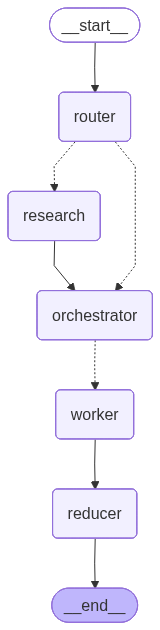

In [40]:
def simple_reducer_node(state: State) -> dict:
    plan = state["plan"]
    if plan is None:
        raise ValueError("simple_reducer_node called without plan.")
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"
    
    filename = f"{_safe_slug(plan.blog_title)}_simple.md"
    Path(filename).write_text(final_md, encoding="utf-8")
    return {"final": final_md}

g_simple = StateGraph(State)
g_simple.add_node("router", router_node)
g_simple.add_node("research", research_node)
g_simple.add_node("orchestrator", orchestrator_node)
g_simple.add_node("worker", worker_node)
g_simple.add_node("reducer", simple_reducer_node)

g_simple.add_edge(START, "router")
g_simple.add_conditional_edges(
    "router", route_next, {"research": "research", "orchestrator": "orchestrator"}
)
g_simple.add_edge("research", "orchestrator")

g_simple.add_conditional_edges("orchestrator", fanout, ["worker"])
g_simple.add_edge("worker", "reducer")
g_simple.add_edge("reducer", END)

app_simple = g_simple.compile()
app_simple


# Testing

In [43]:

input={"topic": "Write a blog on Self Attention","as_of":"01-02-2026", "sections": []}
out=app_simple.invoke(input)

/Users/nitinkumar/Work/SelfBlog/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(needs_rese...ax_results_per_query=10), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
/Users/nitinkumar/Work/SelfBlog/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(blog_title='Self-Att...e, requires_code=True)]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


NameError: name '_safe_slug' is not defined